# ME 323 Module 1 — Choosing the Ground-Truth Model and the Noise Level
### Faculty notebook (staff only — not for students)

The Module 1 student notebooks "test" two class designs against a frozen
**ground-truth (GT) model** — a surrogate for reality, fit to every beam we
have actually broken. This notebook is the receipts for that model: the full
test campaign, the noise level the repeats support, the candidate model
formulations, how they were scored, and why the winner won. It is
self-contained — it loads the three committed campaign CSVs from GitHub and
reproduces the frozen decision end-to-end (≈10–15 min run time; numpy, pandas,
scikit-learn, matplotlib).

**The data.** A 44-beam Latin-hypercube campaign over the original student
design box (b ∈ [1.25, 7], H_web ∈ [5, 16] mm; flange B = 10, total height
18, span 150 mm), plus a 19-test follow-up batch (repeats at five
geometries, fills in under-sampled zones, a thin-web frontier probe at
b = 1.0–1.1 — below the original box edge, and since 2026-07-20 the anchor
of the widened class box b ∈ [1.0, 7] — and three beams printed with
corrected support settings), plus
the 23-print proper-supports recalibration batch of 2026-07-16.
**85 usable tests in all** = 44 + 19 + 22 (one censored proper-supports LTB
test excluded — it was stopped before failure). Deliberately *not* in the
training pool: the 10-test interleaved support experiment (5 proper + 5
improper supports, all at the (1.3, 12.8) anchor). That is a data-selection
choice, stated here so reviewers see it: it is a controlled A/B block at a
single location, and folding in ten more repeats there would let one anchor
(which already carries 10 training tests across the three batches) dominate
the leave-one-location-out scoring below.

> ⚠ **Handling.** This notebook and the campaign CSVs it loads reveal the
> ground truth the students are graded against. They are shared for faculty
> review while the module is in development and will be removed from the
> public repo before the course goes live. Keep them out of anything students
> receive.

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import warnings; warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 120

RAW = ("https://raw.githubusercontent.com/andrewvoss8-boop/"
       "core-me-data-science-activities-public/main/data/")
def load(name):
    try:
        df = pd.read_csv(RAW + name); src = "GitHub"
    except Exception:
        df = pd.read_csv("../../data/" + name); src = "local copy"
    print(f"{name}: {len(df)} rows ({src})")
    return df

# geometry / mass model (identical to the student notebooks)
B_FLANGE, TH, L_SPAN = 10.0, 18.0, 150.0
KMASS = 0.2045                      # g/mm^2 of cross-section at 172 mm printed length
B_LO, B_HI, H_LO, H_HI = 1.0, 7.0, 5.0, 16.0    # student design box (widened from b >= 1.25, 2026-07-20)
def mass_g(b, H):
    return KMASS * (b * H + B_FLANGE * (TH - H))

# one master file: all 86 tests from the 150 mm span experiments
# (44-beam campaign + 19 follow-ups + 23 proper-supports prints), with the
# uniform mass-model strength-to-weight in sw_N_per_g
master = load("ibeam150_master.csv").rename(columns={"b_mm": "b", "H_web_mm": "H",
                                                     "sw_N_per_g": "sw",
                                                     "d_at_peak_mm": "d_at_peak"})
camp = master[master.source == "campaign"].reset_index(drop=True)
add  = master[master.source == "followup"].reset_index(drop=True)
psb  = master[master.source == "ps_recal"].reset_index(drop=True)  # 2026-07-16 batch
print(f"excluding {int(master.censored.sum())} censored PS test (true strength unknown)")

allt = master[~master.censored][["b", "H", "strength_N", "source", "tag"]] \
    .reset_index(drop=True)
allt["sw_true"] = allt.strength_N / mass_g(allt.b, allt.H)
allt["loc"] = allt.b.round(3).astype(str) + "_" + allt.H.round(3).astype(str)
print(f"\ntraining pool: {len(allt)} tests at {allt['loc'].nunique()} distinct geometries")
print("follow-up composition (tag: S1/S2/S3 = repeat sessions, PS = corrected "
      "supports, blank = single tests):")
print(add.tag.fillna("").replace("", "single").value_counts().to_string())

ibeam150_master.csv: 86 rows (local copy)
excluding 1 censored PS test (true strength unknown)

training pool: 85 tests at 53 distinct geometries
follow-up composition (tag: S1/S2/S3 = repeat sessions, PS = corrected supports, blank = single tests):
tag
single    6
S1        4
S2        4
PS        3
S3        2


## 1. Noise, measured from the repeats

Every GP in this study needs a measurement-noise level (`alpha`, the assumed
variance of log strength for a repeated print). The classroom materials assume
**3%**. The follow-up batch was designed to check it: repeated prints at five
geometries, plus the original campaign print where one exists at the same
geometry.

The estimate below pools the **unbiased within-group variances of log
strength, weighted by degrees of freedom**. (An earlier draft of this cell
pooled ddof-0 standard deviations with (n−1) weights, which biases the pooled
value low — that arithmetic printed 3.5%; the corrected pooling lands near
4.4%.) Caveats the number inherits: only five geometries and ~11 degrees of
freedom; the groups that include a campaign print mix print batches, so
batch-to-batch drift is *inside* this number; and three of the groups mix a
proper-supports beam into an otherwise improper-supports set — a systematic
setting change inflating what is being read as aleatory scatter (the `ps_mix`
column flags them).

**Why α = 3% is retained anyway.** The interleaved support experiment and the
PS recalibration batch (staff pipeline, notebooks 17–18) decompose the excess:
within-session proper-supports repeatability is ≈1%, improper supports ≈5%,
between-session drift 5–8%, printer-to-printer ≈4%. The scatter above 3% is
mostly *structured* (session, printer, support condition), which an iid alpha
cannot represent anyway — inflating alpha would smear real geometry signal to
pay for variance that is not iid. The ablation also carries a 3.5% variant to
show the choice barely moves the model ranking. So 3% is a stated working
value, not a measured constant, and treating the structured components as iid
noise is a known simplification of the current GT.

In [2]:
groups = []
for (b, H), g in add.groupby(["b", "H"]):
    vals = list(g.strength_N)
    labels = [t if t else "new" for t in g.tag.fillna("")]
    orig = camp[np.isclose(camp.b, b) & np.isclose(camp.H, H)]
    if len(orig):
        vals = list(orig.strength_N) + vals
        labels = [f"campaign#{int(orig.print_order.iloc[0])}"] + labels
    if len(vals) >= 2:
        groups.append(dict(b=b, H=H, n=len(vals), mean_N=np.mean(vals),
                           ps_mix=bool((g.tag.fillna("") == "PS").any()),
                           sd_log=np.std(np.log(vals), ddof=1),
                           values=np.round(vals, 1).tolist(), sessions=labels))
grp = pd.DataFrame(groups)
print(grp[["b", "H", "n", "mean_N", "sd_log", "ps_mix", "values"]].round(3).to_string(index=False))

ss  = sum((r.n - 1) * r.sd_log**2 for _, r in grp.iterrows())
dof = sum(r.n - 1 for _, r in grp.iterrows())
sigma_pooled = float(np.sqrt(ss / dof))
print(f"\npooled print-to-print noise: {sigma_pooled*100:.1f}% (log-space sd, {dof} dof; "
      "unbiased within-group variances, (n-1)-weighted)")
print("assumed classroom alpha: 3.0% -- retained as a stated working value; see the")
print("markdown above for the component breakdown and why alpha is not inflated to match")

   b     H  n  mean_N  sd_log  ps_mix                              values
1.25 13.40  2 485.800   0.044   False                      [470.8, 500.8]
1.30 12.80  5 551.420   0.031    True [548.6, 524.2, 565.2, 566.1, 553.0]
1.74 14.88  3 391.433   0.051    True               [376.1, 383.8, 414.4]
2.05 10.10  2 703.850   0.088    True                      [747.5, 660.2]
2.70  9.40  4 801.325   0.029   False        [833.7, 782.5, 787.3, 801.8]

pooled print-to-print noise: 4.4% (log-space sd, 11 dof; unbiased within-group variances, (n-1)-weighted)
assumed classroom alpha: 3.0% -- retained as a stated working value; see the
markdown above for the component breakdown and why alpha is not inflated to match


## 2. The candidate formulations

Same question the students face in Submission 1, asked at full scale: where,
if anywhere, do the physics equations belong inside the model? Each candidate
below is one answer; the GP-based ones come in RBF and Matérn (ν = 2.5)
kernel flavors. The Matérn allows rougher functions than the very smooth RBF.
With real failure modes switching across the map, that flexibility is worth
testing rather than assuming.

| variant | inputs → target | student-notebook analogue |
|---|---|---|
| `phys` | `P_phys`, no fitting | Pre-lab 1 hand-calc capacity |
| `phys_cal` | physics × one fitted log-space scale | a one-knob calibration |
| `gp_sw` | GP (b, H_web) → log str/w | Submission 1 lane A |
| `gp_str` | GP (b, H_web) → log strength | lane B |
| `gpf_sw` | GP (b, H_web, log P_phys, stab) → log str/w | lane C (physics features) |
| `gpr_str` | GP (b, H_web) → log(strength / P_phys) | lane D (residual) |

### The physics feature `P_phys`

`P_phys` is where the failure physics enters — and every variant except the
pure-ML `gp_*` lanes consumes it. The GT winner is `gpf_sw_matern`, a
*physics-informed* model, so **the shear model is part of the ground truth**,
not a side calculation. The capacity is the minimum of three competing modes:

$$P_{sep} = 2\,\tau_i\,\frac{I_x t_w}{Q_f},\qquad
Q_f = B\,t_f\,\frac{h_w + t_f}{2},\qquad
P_{phys} = \min\!\left(P_{bend},\, P_{sep},\, P_{LTB}\right)$$

The shear term is **shear flow on the flange–web junction** — the plane every
observed shear-type failure actually fractured — checked against the strength
along the printed layer lines τᵢ, competing as a separate mode. The case for
it — the fracture notes, the back-calculation constancy test (CoV 15%), the
population check, and the rejected pointwise von Mises alternative — is in
`ME323_Module1_Shear_Model_Selection_FACULTY.ipynb`.

**The τᵢ parameter.** Unlike σ_y = 76 MPa (a handbook value), τᵢ is the strength
along the printed layer lines — weaker than the bulk material — and must come
from test data. Three candidates are scored:

| τᵢ | source | independence |
|---|---|---|
| 17.45 MPa | back-calculated from the campaign's 4 clean separations | fit on these data |
| 14.56 MPa | pooled over all 9 clean separations, every batch | fit on these data |
| 11.40 MPa | published short-beam-shear ILSS for FDM PLA | **independent of our data** |

The first two are mildly circular — τᵢ is informed by beams that LOLO later
hides — so the leak-free literature value is carried as the honesty check. If
the τᵢ choice barely moves the score, the circularity does not matter much;
Section 3 reports exactly that.

**Naming.** The zoo names below are local to this notebook; the staff
pipeline's `gt_model_choice.json` records the same winning formulation as
`gpf_sw_matern_sep` (the `_sep` suffix marks the junction-shear feature set).
One naming hazard for anyone auditing the stability table in Section 4: the
63-test era also had a winner *called* `gpf_sw_matern`, but that name then
referred to the old interaction-surrogate feature — same label, different
physics.

Shared recipe, identical to the student notebooks: z-scored inputs, log
target, mean-centered, `alpha = 0.03²` unless stated, 5 optimizer restarts,
fixed seed. The physics is otherwise the uncalibrated handbook version
(σ_y = 76 MPa, fixture k = 0.33); the GT must not depend on the class's
calibration exercise.

In [3]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel as CK, RBF, Matern

# ---- physics (identical to ibeam150_common.py / the student notebooks) ----
SY, E_MOD = 76e6, 2.5e9
G_MOD, C1_LTB, C2_LTB, K_FIX = E_MOD / 2.6, 1.35, 0.55, 0.33
TAU_I_CAMPAIGN, TAU_I_POOLED, TAU_I_LIT = 17.45e6, 14.56e6, 11.40e6

def section_props(b, H):
    tf = (TH - H) / 2.0
    b_, h_, B_, tf_ = b / 1e3, H / 1e3, B_FLANGE / 1e3, tf / 1e3
    c = (TH / 1e3) / 2.0
    Ix = (b_*h_**3)/12 + 2*((B_*tf_**3)/12 + B_*tf_*(h_/2 + tf_/2)**2)
    Iy = (h_*b_**3)/12 + 2*(tf_*B_**3)/12
    beta = lambda t, a: 1 - 0.63*(t/a) + 0.052*(t/a)**5
    J  = (1/3)*beta(b_, h_)*h_*b_**3 + (2/3)*beta(tf_, B_)*B_*tf_**3
    Cw = Iy*(h_ + tf_)**2/4
    return dict(Ix=Ix, Iy=Iy, J=J, Cw=Cw, c=c, b=b_, h=h_, tf=tf_)

def _P_bend(p):
    return 4*SY*p["Ix"]/(p["c"]*L_SPAN/1e3)

def _P_LTB(p, k=K_FIX):
    My = SY*p["Ix"]/p["c"]
    Lb, zg = k*L_SPAN/1e3, p["c"]
    R = p["Cw"]/p["Iy"] + (Lb**2*G_MOD*p["J"])/(np.pi**2*E_MOD*p["Iy"]) + (C2_LTB*zg)**2
    Mcr = C1_LTB*np.pi**2*E_MOD*p["Iy"]/Lb**2 * (np.sqrt(R) - C2_LTB*zg)
    return 4*min(My, Mcr)/(L_SPAN/1e3)

def phys_parts(b, H, tau_i=TAU_I_CAMPAIGN, k=K_FIX):
    """(P_bend, P_sep, P_LTB, P_phys) in N.

    P_sep is junction shear flow checked against tau_i, the strength along the
    printed layer lines; P_phys is the minimum of the three competing modes.
    """
    p = section_props(b, H)
    Pb, Pl = _P_bend(p), _P_LTB(p, k)
    Qf = (B_FLANGE/1e3)*p["tf"]*(p["h"]/2 + p["tf"]/2)        # flange first moment
    Psep = 2*tau_i*p["Ix"]*p["b"]/Qf                          # junction shear flow
    return Pb, Psep, Pl, min(Pb, Psep, Pl)

# ---- the model zoo ----
def _make_gp(n_dims, kernel_kind, alpha, n_restarts=5, seed=0):
    if kernel_kind == "rbf":
        ker = CK(1.0, (1e-3, 1e3)) * RBF([1.0]*n_dims, (1e-1, 30.0))
    else:
        ker = CK(1.0, (1e-3, 1e3)) * Matern([1.0]*n_dims, (1e-2, 30.0), nu=2.5)
    return GaussianProcessRegressor(ker, alpha=alpha, normalize_y=False,
                                    n_restarts_optimizer=n_restarts, random_state=seed)

class BeamModel:
    """One zoo entry. fit(df) then predict(b, H) -> (strength_N, sw[, sigma_log])."""
    def __init__(self, variant, kernel_kind="rbf", alpha=0.03**2,
                 tau_i=TAU_I_CAMPAIGN):
        self.variant, self.kernel_kind, self.alpha = variant, kernel_kind, alpha
        self.tau_i = tau_i

    def _phys_cols(self, b, H):
        parts = np.array([phys_parts(bb, HH, self.tau_i)
                          for bb, HH in zip(b, H)])
        Pb, Ps, Pl, Pphys = parts.T
        return Pphys, Pl / Pb                         # P_phys, stab

    def _X(self, b, H):
        b, H = np.asarray(b, float), np.asarray(H, float)
        if self.variant in ("gp_sw", "gp_str", "gpr_str"):
            return np.column_stack([b, H])
        Pphys, stab = self._phys_cols(b, H)
        return np.column_stack([b, H, np.log(Pphys), stab])

    def fit(self, df):
        b, H, y_str = df.b.values, df.H.values, df.strength_N.values
        if self.variant == "phys":
            return self
        if self.variant == "phys_cal":
            Pphys, _ = self._phys_cols(b, H)
            self.scale_ = float(np.exp(np.mean(np.log(y_str) - np.log(Pphys))))
            return self
        if self.variant in ("gp_sw", "gpf_sw"):
            y = np.log(y_str / mass_g(b, H))
        elif self.variant in ("gp_str", "gpf_str"):
            y = np.log(y_str)
        else:                                        # gpr_str
            Pphys, _ = self._phys_cols(b, H)
            y = np.log(y_str) - np.log(Pphys)
        X = self._X(b, H)
        self.fmu_, self.fsd_ = X.mean(0), X.std(0) + 1e-12
        self.ymean_ = y.mean()
        self.gp = _make_gp(X.shape[1], self.kernel_kind, self.alpha)
        self.gp.fit((X - self.fmu_) / self.fsd_, y - self.ymean_)
        return self

    def predict(self, b, H, return_std=False):
        b, H = np.atleast_1d(np.asarray(b, float)), np.atleast_1d(np.asarray(H, float))
        m = mass_g(b, H)
        if self.variant == "phys":
            Pphys, _ = self._phys_cols(b, H)
            s, sig = Pphys, np.zeros(len(b))
        elif self.variant == "phys_cal":
            Pphys, _ = self._phys_cols(b, H)
            s, sig = self.scale_ * Pphys, np.zeros(len(b))
        else:
            mu, sig = self.gp.predict((self._X(b, H) - self.fmu_) / self.fsd_,
                                      return_std=True)
            mu = mu + self.ymean_
            if self.variant in ("gp_sw", "gpf_sw"):
                s = np.exp(mu) * m
            elif self.variant in ("gp_str", "gpf_str"):
                s = np.exp(mu)
            else:
                Pphys, _ = self._phys_cols(b, H)
                s = Pphys * np.exp(mu)
        return (s, s/m, sig) if return_std else (s, s/m)

# every entry uses the junction-shear physics (P_phys = min(P_bend, P_sep, P_LTB)).
ZOO = {
    "phys_pure":         dict(variant="phys"),
    "phys_calibrated":   dict(variant="phys_cal"),
    "gp_sw_rbf":         dict(variant="gp_sw",  kernel_kind="rbf"),
    "gp_sw_matern":      dict(variant="gp_sw",  kernel_kind="matern"),
    "gp_sw_matern_a3.5": dict(variant="gp_sw",  kernel_kind="matern", alpha=0.035**2),
    "gp_str_matern":     dict(variant="gp_str", kernel_kind="matern"),
    "gpf_sw_rbf":        dict(variant="gpf_sw", kernel_kind="rbf"),
    "gpf_sw_matern":     dict(variant="gpf_sw", kernel_kind="matern"),
    "gpr_str_rbf":       dict(variant="gpr_str", kernel_kind="rbf"),
    "gpr_str_matern":    dict(variant="gpr_str", kernel_kind="matern"),
}
print(len(ZOO), "candidates, all on the junction-shear physics:")
print("  " + ", ".join(ZOO))
print(f"\ntau_i for the physics feature: {TAU_I_CAMPAIGN/1e6:.2f} MPa "
      f"(sensitivity to this choice is measured in Section 3)")

10 candidates, all on the junction-shear physics:
  phys_pure, phys_calibrated, gp_sw_rbf, gp_sw_matern, gp_sw_matern_a3.5, gp_str_matern, gpf_sw_rbf, gpf_sw_matern, gpr_str_rbf, gpr_str_matern

tau_i for the physics feature: 17.45 MPa (sensitivity to this choice is measured in Section 3)


## 3. Scoring: leave-one-LOCATION-out

With repeats in the pool, plain leave-one-out is subtly rigged: hide one print
of a repeated geometry and its siblings stay in training, so the model gets
credit for memorizing that site rather than for generalizing. The fix is
**leave-one-location-out (LOLO)**: all prints of a geometry leave together. The
cell below runs LOLO for every candidate — and, for the two leading GPs, also
runs plain LOO so you can see the size of the leak the protocol removes.

Errors are scored in strength-to-weight space (N/g), the quantity the module
optimizes. The final block re-scores the leading physics-informed GP at all
three τᵢ values, including the leak-free literature one.

phys_pure              LOLO sw RMSE 8.484  MAPE 20.74%  R2 -3.831
phys_calibrated        LOLO sw RMSE 4.378  MAPE 9.84%  R2 -0.286


gp_sw_rbf              LOLO sw RMSE 2.616  MAPE 6.30%  R2 +0.541


gp_sw_matern           LOLO sw RMSE 2.564  MAPE 6.21%  R2 +0.559


gp_sw_matern_a3.5      LOLO sw RMSE 2.567  MAPE 6.23%  R2 +0.558


gp_str_matern          LOLO sw RMSE 3.171  MAPE 7.56%  R2 +0.325


...

  gpf_sw_matern      plain LOO 2.154  vs  LOLO 2.216 N/g


  gp_sw_matern       plain LOO 2.459  vs  LOLO 2.564 N/g

tau_i sensitivity for gpf_sw_matern (LOLO sw RMSE):


  tau_i = 17.45 campaign (4 seps)  2.216


  tau_i = 14.56 pooled (9 seps)    2.244


  tau_i = 11.40 literature ILSS    2.299
  -> the three tau_i values barely separate, including the leak-free
     literature one: the physics feature is robust to the fitted constant.


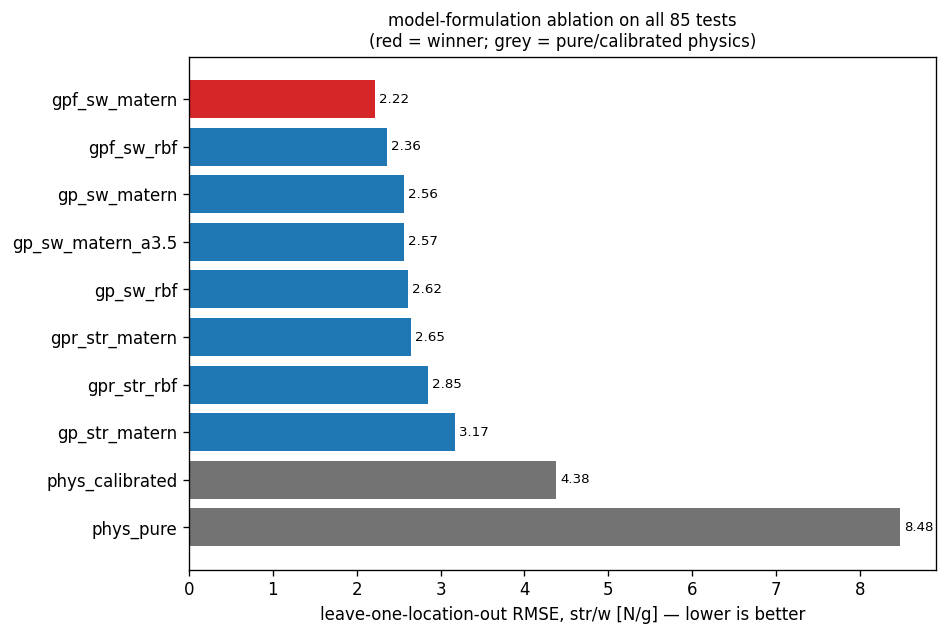

In [4]:
def metrics(y_true, y_pred, prefix=""):
    y_true, y_pred = np.asarray(y_true, float), np.asarray(y_pred, float)
    err = y_pred - y_true
    ss = np.sum((y_true - y_true.mean())**2)
    return {prefix + "rmse": float(np.sqrt(np.mean(err**2))),
            prefix + "mae": float(np.mean(np.abs(err))),
            prefix + "mape_pct": float(np.mean(np.abs(err / y_true)) * 100),
            prefix + "r2": float(1 - np.sum(err**2)/ss)}

locs = allt["loc"].unique()

def lolo_sw(kw):
    """Leave-one-location-out str/w predictions for one zoo entry."""
    preds = np.zeros(len(allt))
    for L in locs:
        te = (allt["loc"] == L).values
        mdl = BeamModel(**kw).fit(allt[~te])
        _, sw = mdl.predict(allt.b.values[te], allt.H.values[te])
        preds[te] = sw
    return preds

rows = []
for name, kw in ZOO.items():
    preds = lolo_sw(kw)
    rows.append({"model": name, **metrics(allt.sw_true, preds, "sw_")})
    print(f"{name:22s} LOLO sw RMSE {rows[-1]['sw_rmse']:.3f}  "
          f"MAPE {rows[-1]['sw_mape_pct']:.2f}%  R2 {rows[-1]['sw_r2']:+.3f}")

tbl = pd.DataFrame(rows).sort_values("sw_rmse").reset_index(drop=True)
winner = tbl.iloc[0]
print(f"\nWINNER: {winner.model}  (LOLO sw RMSE {winner.sw_rmse:.3f} N/g on {len(allt)} tests)")
print("(the staff pipeline records this winner as gpf_sw_matern_sep in gt_model_choice.json;")
print(" this notebook does not write that file)")

# the leak plain LOO would have hidden
print("\nplain LOO vs LOLO (the repeat leak):")
for name in ["gpf_sw_matern", "gp_sw_matern"]:
    preds = np.zeros(len(allt))
    for i in range(len(allt)):
        mdl = BeamModel(**ZOO[name]).fit(allt.drop(allt.index[i]))
        _, sw = mdl.predict(allt.b.iloc[i], allt.H.iloc[i])
        preds[i] = sw[0]
    loo_rmse = np.sqrt(np.mean((preds - allt.sw_true.values)**2))
    lolo_rmse = tbl.loc[tbl.model == name, "sw_rmse"].iloc[0]
    print(f"  {name:18s} plain LOO {loo_rmse:.3f}  vs  LOLO {lolo_rmse:.3f} N/g")

# how much does the tau_i choice actually matter?
print("\ntau_i sensitivity for gpf_sw_matern (LOLO sw RMSE):")
tau_rows = []
for lbl, tv in [("17.45 campaign (4 seps)", TAU_I_CAMPAIGN),
                ("14.56 pooled (9 seps)", TAU_I_POOLED),
                ("11.40 literature ILSS", TAU_I_LIT)]:
    r = np.sqrt(np.mean((lolo_sw(dict(variant="gpf_sw", kernel_kind="matern",
                                      tau_i=tv))
                         - allt.sw_true.values)**2))
    tau_rows.append((lbl, r))
    print(f"  tau_i = {lbl:24s} {r:.3f}")
print("  -> the three tau_i values barely separate, including the leak-free\n"
      "     literature one: the physics feature is robust to the fitted constant.")

fig, ax = plt.subplots(figsize=(8, 5.4))
t2 = tbl.iloc[::-1]
cols = ["tab:red" if m == winner.model else
        ("0.45" if m.startswith("phys") else "tab:blue") for m in t2.model]
ax.barh(t2.model, t2.sw_rmse, color=cols)
for y, (m, v) in enumerate(zip(t2.model, t2.sw_rmse)):
    ax.annotate(f"{v:.2f}", (v + 0.05, y), va="center", fontsize=8)
ax.set_xlabel("leave-one-location-out RMSE, str/w [N/g] — lower is better")
ax.set_title(f"model-formulation ablation on all {len(allt)} tests\n"
             "(red = winner; grey = pure/calibrated physics)", fontsize=10)
plt.tight_layout(); plt.show()

## 4. What the winner is, and how stable this choice has been

**`gpf_sw_matern`** — a GP with inputs `(b, H_web, log P_phys, stab)`, where
`P_phys = min(P_bend, P_sep(τᵢ), P_LTB(k=0.33))`, `P_sep` is the flange–web
junction shear-flow capacity at τᵢ = 17.45 MPa, and `stab = P_LTB/P_bend`.
The target is `log(strength / estimated mass)`. The kernel is
Constant × Matérn(ν = 2.5) with per-dimension length scales, `alpha = 0.03²`,
z-scored inputs, mean-centered target, fixed seed.

**Why the physics enters as a feature, not a baseline.** The lanes split by how
they consume `P_phys`. The *feature* lanes (`gpf_*`) hand it to the GP as an
input and let the GP fit its own correction; the *baseline* lanes (`gpr_*`,
`phys_cal`, `phys`) multiply predictions through the physics and inherit its
bias directly. The uncalibrated handbook σ_y = 76 MPa over-predicts flexural
capacity by ~13%, so the baseline lanes carry that bias raw — which is why the
`phys_*` rows sit well back in the ablation. A GP with the physics as a feature
does not care: it only wants the feature to have the right *shape and mode
structure*, which the junction-shear term supplies. The honest fix for the
baseline lanes is calibrated σ_y — exactly what Pre-lab 1 has students do
(their `phys` lane fits σ_y, k, and τᵢ) — but the `phys_*` rows here are kept
uncalibrated so the GT does not depend on the class's calibration exercise.

**τᵢ barely matters to the GT.** The Section-3 sweep moves the leading GP by a
few hundredths of a N/g across 17.45 / 14.56 / 11.40 MPa; the leak-free
literature value scores essentially the same, so the physics feature is robust
to the fitted constant.

**Honesty about stability.** The winning *formulation* has moved as the data grew:

| data state | winner |
|---|---|
| 43 beams (before beam 23's trace was recovered) | `gpf_sw_rbf` |
| 44 beams, plain LOOCV | `gp_sw_matern` |
| 63 tests, leave-one-location-out | `gpf_sw_matern` (old interaction-surrogate feature — same name, different physics) |
| full pool (incl. proper-supports batch), LOLO | `gpf_sw_matern` (junction-shear feature; recorded as `gpf_sw_matern_sep` in the staff pipeline) |

Read the ablation bars accordingly: the top GP variants sit within a few
tenths of a N/g of each other, and single influential beams have reordered
them before. What has stayed stable across every re-evaluation: (1) a GP beats
pure or calibrated physics by a wide margin, (2) the str/w target beats the
raw-strength target, and (3) physics features help most at the edges of the
data. The class-facing consequences of swapping among the top two or three
GPs are small.

**Consumption.** The two class-wide designs are evaluated once against this GT
mean and the resulting numbers frozen into the student notebooks; regenerating
the student notebooks (`run13`) propagates the GT to the class query values.
The cell below fits the GT and reports its in-box optimum and the GT values at
the two frozen class designs.

GT optimum inside the student box: 40.73 N/g at (1.34, 12.30)
fitted GT kernel: 0.117**2 * Matern(length_scale=[1.24, 0.402, 1.25, 30], nu=2.5)

GT values at the two frozen class designs (ground_truth.py coordinates):
design                str/w   strength           frozen
equation beam      38.01 N/g    482.6 N   38.02 N/g / 482.6 N
GP beam            36.06 N/g    438.7 N   36.06 N/g / 438.7 N

nearest physically printed tests (for comparison only, these are
NOT the frozen class coordinates -- no print sits within 0.2 mm of
either frozen design):
  same-b neighbor of eq beam   (1.1, 12.5):  37.84 N/g    532.0 N
  diagonal neighbor of eq beam (1.25, 13.4):  38.32 N/g    491.8 N
  same-b neighbor of GP beam   (1.0, 12.5):  35.11 N/g    484.6 N


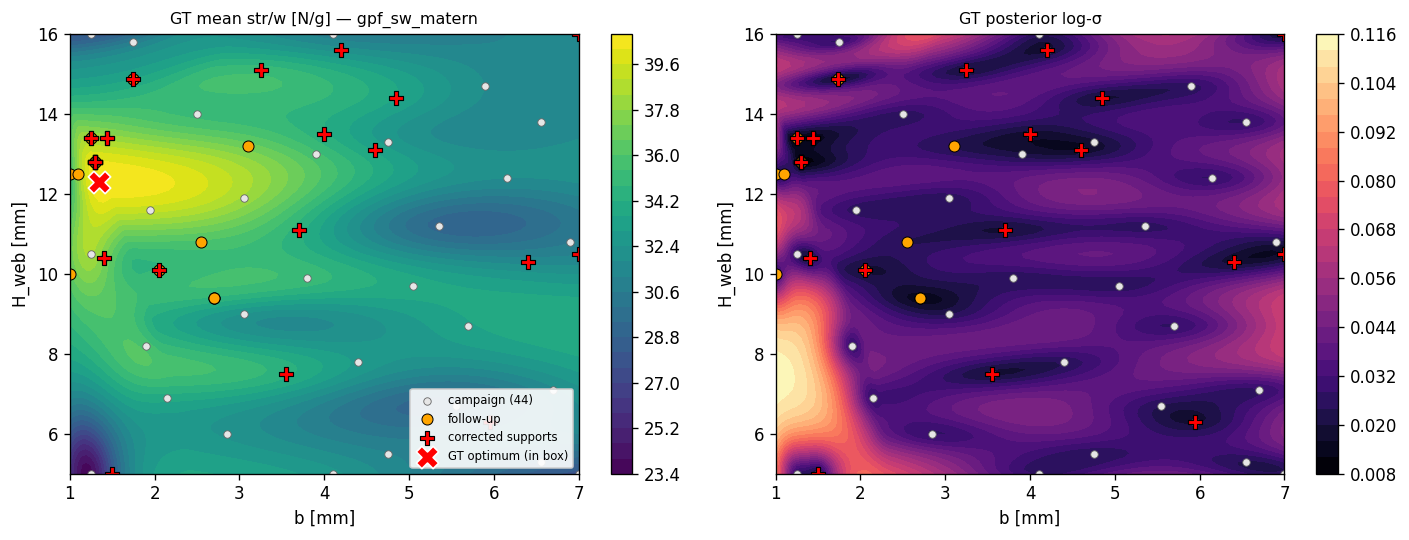

In [5]:
GT = BeamModel(**ZOO[winner.model]).fit(allt)

bg = np.linspace(1.0, B_HI, 124); Hg = np.linspace(H_LO, H_HI, 111)
BB, HH = np.meshgrid(bg, Hg)

def surf(model):
    _, SWf, SIGf = model.predict(BB.ravel(), HH.ravel(), return_std=True)
    return SWf.reshape(BB.shape), SIGf.reshape(BB.shape)

SW, SIG = surf(GT)

def optimum(SW):
    io = np.unravel_index(np.argmax(np.where(BB >= B_LO, SW, -np.inf)), SW.shape)
    return SW[io], BB[io], HH[io], io

v, bo, ho, io = optimum(SW)
print(f"GT optimum inside the student box: {v:.2f} N/g at ({bo:.2f}, {ho:.2f})")

print("fitted GT kernel:", GT.gp.kernel_)

print("\nGT values at the two frozen class designs (ground_truth.py coordinates):")
FROZEN = [((1.10, 13.25), "equation beam", 38.02, 482.6),
          ((1.00, 13.39), "GP beam", 36.06, 438.7)]
print(f"{'design':16s} {'str/w':>10s} {'strength':>10s} {'frozen':>16s}")
for (bq, Hq), label, sw_frozen, N_frozen in FROZEN:
    s, sw = GT.predict([bq], [Hq])
    print(f"{label:16s} {sw[0]:7.2f} N/g {s[0]:8.1f} N   {sw_frozen:.2f} N/g / {N_frozen:.1f} N")
    assert abs(sw[0] - sw_frozen) < 0.05, (
        f"{label}: GT mean {sw[0]:.3f} N/g does not reproduce the frozen "
        f"{sw_frozen} N/g -- STOP and reconcile before trusting either number")

print("\nnearest physically printed tests (for comparison only, these are")
print("NOT the frozen class coordinates -- no print sits within 0.2 mm of")
print("either frozen design):")
for (bq, Hq), label in [((1.10, 12.50), "same-b neighbor of eq beam"),
                        ((1.25, 13.40), "diagonal neighbor of eq beam"),
                        ((1.00, 12.50), "same-b neighbor of GP beam")]:
    s, sw = GT.predict([bq], [Hq])
    print(f"  {label:28s} ({bq}, {Hq}): {sw[0]:6.2f} N/g  {s[0]:7.1f} N")

fig, ax = plt.subplots(1, 2, figsize=(12, 4.6))
m_c, m_f, m_p = (allt.source == "campaign"), (allt.source == "followup"), (allt.tag == "PS")
for a, Z, ttl, cmap in [(ax[0], SW, f"GT mean str/w [N/g] — {winner.model}", "viridis"),
                        (ax[1], SIG, "GT posterior log-σ", "magma")]:
    cf = a.contourf(BB, HH, Z, levels=30, cmap=cmap)
    plt.colorbar(cf, ax=a)
    a.scatter(allt.b[m_c], allt.H[m_c], s=20, c="0.9", edgecolor="0.4", lw=0.5,
              label="campaign (44)")
    a.scatter(allt.b[m_f], allt.H[m_f], s=44, c="orange", edgecolor="k", lw=0.6,
              label="follow-up")
    a.scatter(allt.b[m_p], allt.H[m_p], s=80, marker="P", c="red", edgecolor="k",
              lw=0.7, label="corrected supports")
    a.axvline(B_LO, color="0.2", ls=":", lw=1)
    a.set_xlabel("b [mm]"); a.set_ylabel("H_web [mm]"); a.set_title(ttl, fontsize=9.5)
ax[0].scatter([BB[io]], [HH[io]], marker="X", s=180, c="red", edgecolor="w",
              zorder=5, label="GT optimum (in box)")
ax[0].legend(fontsize=7, loc="lower right", framealpha=0.9)
plt.tight_layout(); plt.show()

## 5. Caveats that should travel with this model

1. **τᵢ is mildly circular, and it drifts.** The winning feature uses
   τᵢ = 17.45 MPa, back-calculated from four campaign separations that LOLO
   later hides — a small leak (one scalar, entering only a deterministic
   function of geometry, so no beam can be memorized through it). The τᵢ sweep
   in Section 3 is the check: the leak-free literature value (11.40 MPa) also
   beats the old formulation, so the win survives removing the circularity.
   Separately, τᵢ is a *printed-joint* property, not a material constant. The
   value now appears in several defensible flavors: **17.45 MPa** (campaign
   back-calculation, n = 4 — the GT feature), **16.76 MPa** (the class's
   15-beam joint calibration in Pre-lab 1, after the b = 1.0 seed beam
   joined the handout), **≈14.6 MPa** (pooled over all 9
   clean separations), **≈13.5 MPa, CoV ≈30%** (the proper-supports batch's
   separations), **11.4 MPa** (literature ILSS). It moves with print session
   and support settings. The shear-model notebook recommends carrying it as a
   distribution; the GT uses the campaign point value for freeze consistency
   and lets the GP absorb the rest — defensible exactly because the Section-3
   sweep shows the model ranking barely feels the constant.
2. **The support-condition mix.** During the campaign, print supports were
   generating as individual lines instead of the intended zigzag; later
   batches print with corrected ("proper") supports, which is also the
   go-forward class print condition. What the evidence now says, in order:
   the three cross-session PS beams below read *weaker* — that comparison is
   printed for the record, but it was a **session confound**, retracted by
   the controlled 10-beam interleaved experiment (proper supports **+7.2%
   stronger** at the anchor, t ≈ 3.2, and ~5× more repeatable; staff
   notebook 17). The 23-print recalibration batch then showed the effect is
   **mode-dependent**, not a scale factor: separation-prone thin-web beams
   +5.6…+10.6%, some stocky bend beams −8.6…−4% (staff notebook 18; the
   pooled printer-corrected "+0.3%" is a misleading average of that spread).
   The GT pools **60 improper-support and 25 proper-support tests with no
   condition covariate**, so at the thin-web ridge — where grading happens —
   the GT mean likely reads a few percent *low* for proper-support prints,
   partially offset by the 25 PS tests that re-covered the ridge. Ground-truth query
   policy v3 (real proper-support means wherever a coordinate was physically
   printed, GT mean elsewhere) sidesteps this at printed coordinates. One
   gap to keep in view: the 2026-07-20 frozen coordinates — equation beam
   (1.10, 13.25), GP beam (1.00, 13.39) — have no proper-support prints
   within 0.2 mm; the nearest tests are single old-support prints at
   (1.10, 12.50) and (1.00, 12.50). Exact-coordinate grounding prints at
   both frozen designs are on the next-batch list.
3. **The thin-web frontier is uncertain, and only the data knows how.** Of the
   follow-up probes at b = 1.0–1.1 (outside the original box; now inside the
   widened one, and the only anchors it has), the taller-web ones
   carried well under what campaign-calibrated physics promises — failing by
   flange–web separation — while the shortest-web probe over-performed
   instead. The new shear model gives that mode a mechanism for the first
   time, which is much of why the physics-informed GPs improved; it does not
   make the frontier certain.
4. **Noise: ≈4.4% measured vs 3% assumed.** Section 1's corrected pooling
   puts the repeat scatter near 4.4%, above the classroom 3% — but the excess
   is structured (session, printer, support condition), not iid, and the
   `gp_sw_matern` vs `gp_sw_matern_a3.5` ablation rows show the alpha choice
   is far below the resolution of the model comparison. The classroom 3%
   stands as a stated working value, with the mismatch documented rather than
   hidden.
5. **The fitted kernel rides its length-scale bound.** The winning fit pins
   at least one physics-feature length scale at the optimizer's upper bound
   (30 in z-scored units; the fitted kernel is printed under the GT fit, and
   the ConvergenceWarning is otherwise suppressed by the notebook's warnings
   filter). A pinned length scale means the marginal likelihood wanted an
   even flatter direction than the box allows — the fit is usable, but the
   hyperparameter is at its box and the bound, not the data, chose it.
6. **Selection measures interpolation.** LOLO scores predictions at geometries
   surrounded by other tested geometries. Extrapolation quality outside the
   tested cloud is not scored — one reason the frozen class queries return GT
   values only at well-supported points.
7. **The GT embeds the physics it is scored with.** Because the winner takes
   `log P_phys` as a feature, the ground truth inherits our failure-mode
   assumptions (now including τᵢ and k = 0.33). This mildly flatters
   physics-informed variants in any downstream study that scores against this
   GT — a known limitation of using a PI model as the ground truth, unchanged in
   kind by this update but worth restating now that the physics has moved.
8. **The LTB–separation blur is handled by the GP, not the physics.**
   `P_phys` keeps the clean three-way min(); the subsection below shows the
   GP learns the corner knockdown out-of-sample, why the five LTB-family
   beams are load-bearing training data, and why the posterior σ near mode
   boundaries is optimistic.

In [6]:
# corrected-support (PS) beams vs same-geometry old-support prints
print("PS vs old-support prints, same geometry (z in units of pooled noise):")
zs = []
for (b, H) in add[add.proper_supports][["b", "H"]].itertuples(index=False):
    g = add[(add.b == b) & (add.H == H)]
    ps = g[g.proper_supports].iloc[0]
    old_N = list(g[~g.proper_supports].strength_N) + \
            list(camp[np.isclose(camp.b, b) & np.isclose(camp.H, H)].strength_N)
    dlog = np.log(ps.strength_N) - np.mean(np.log(old_N))
    z = dlog / sigma_pooled
    zs.append(z)
    print(f"  ({b}, {H}):  PS {ps.strength_N:.1f} N vs old mean {np.mean(old_N):.1f} N "
          f"(n={len(old_N)})  ->  {np.exp(dlog)*100-100:+.1f}%  (z = {z:+.2f})")
verdict = ("all weaker" if all(z < 0 for z in zs)
           else "all stronger" if all(z > 0 for z in zs) else "mixed")
print(f"combined z = {sum(zs)/np.sqrt(len(zs)):+.2f}  ({verdict})")
print("NOTE: this three-beam comparison crosses print sessions; the controlled")
print("interleaved experiment later showed the session, not the supports, drove it")
print("(proper supports are +7.2% STRONGER when session is held fixed -- caveat 2).")

# the thin-web frontier: measured vs physics calibrated on the pre-frontier campaign
pc = BeamModel(variant="phys_cal").fit(allt[allt.source == "campaign"])
frontier = add[add.b <= 1.1]
print("\nthin-web frontier (b <= 1.1; outside the original campaign box,"
      " inside the widened class box):")
for _, r in frontier.iterrows():
    _, sw_pc = pc.predict([r.b], [r.H])
    print(f"  ({r.b}, {r.H}):  measured {r.sw:.1f} N/g   vs  campaign-calibrated "
          f"physics {sw_pc[0]:.1f} N/g   — {r.failure_note[:60]}")

PS vs old-support prints, same geometry (z in units of pooled noise):
  (1.3, 12.8):  PS 524.2 N vs old mean 558.2 N (n=4)  ->  -6.1%  (z = -1.43)
  (1.74, 14.88):  PS 376.1 N vs old mean 399.1 N (n=2)  ->  -5.7%  (z = -1.34)
  (2.05, 10.1):  PS 660.2 N vs old mean 747.5 N (n=1)  ->  -11.7%  (z = -2.83)
combined z = -3.23  (all weaker)
NOTE: this three-beam comparison crosses print sessions; the controlled
interleaved experiment later showed the session, not the supports, drove it
(proper supports are +7.2% STRONGER when session is held fixed -- caveat 2).

thin-web frontier (b <= 1.1; outside the original campaign box, inside the widened class box):
  (1.0, 10.0):  measured 36.4 N/g   vs  campaign-calibrated physics 24.3 N/g   — Seperation of the top flange from the web. Vertical crack al
  (1.0, 12.5):  measured 34.4 N/g   vs  campaign-calibrated physics 35.8 N/g   — Seperation of the top flange from the web. Interface between
  (1.1, 12.5):  measured 38.5 N/g   vs  campaign-calibrat

### The LTB–separation blur corner: does the GP learn it?

The physics feature treats separation and LTB as independent competing modes
— a clean min() — but the tall-thin corner couples them: twist peels the
flange–web joint below either pure capacity (shear notebook, section 8b). The
adopted strategy is to keep the hand physics clean and let the GP own the
interaction. That is a testable claim: hold out each LTB-family *location*
entirely, refit `gpf_sw_matern`, and ask what it predicts there.

In [7]:
CORNER = [("print 3 — sep note, LTB-governed", 1.25, 16.0),
          ("print 35 — LTB note", 1.75, 15.8),
          ("follow-up LTB trio", 1.74, 14.88)]

def fit_corner(train):
    return BeamModel(**ZOO["gpf_sw_matern"]).fit(train)

def at_loc(bq, Hq):
    return np.isclose(allt.b, bq, atol=0.006) & np.isclose(allt.H, Hq, atol=0.006)

print("leave-the-location-out at the LTB-family geometries:")
print(f"{'location':<34} {'meas N':>6} {'P_phys':>7} {'GP':>6} {'GP err':>7} {'phys err':>9}")
corner_mask = np.zeros(len(allt), bool)
for name, bq, Hq in CORNER:
    te = at_loc(bq, Hq)
    corner_mask |= te
    meas = allt.strength_N[te].mean()
    Pphys = phys_parts(bq, Hq)[3]
    s, _, sig = fit_corner(allt[~te]).predict([bq], [Hq], return_std=True)
    print(f"{name:<34} {meas:>6.0f} {Pphys:>7.0f} {s[0]:>6.0f} "
          f"{100*(s[0]-meas)/meas:>+6.0f}% {100*(Pphys-meas)/meas:>+8.0f}%")

print(f"\nsame predictions with ALL {int(corner_mask.sum())} LTB-family beams dropped:")
gp_nc = fit_corner(allt[~corner_mask])
for name, bq, Hq in CORNER:
    meas = allt.strength_N[at_loc(bq, Hq)].mean()
    s, _, sig = gp_nc.predict([bq], [Hq], return_std=True)
    print(f"  {name:<32} GP {s[0]:>4.0f} N ({100*(s[0]-meas)/meas:+.0f}%)   log-sigma {sig[0]:.3f}")

gp_full = fit_corner(allt)
_, _, sig3 = gp_full.predict([1.25], [16.0], return_std=True)
bb, hh = np.meshgrid(np.linspace(B_LO, B_HI, 60), np.linspace(H_LO, H_HI, 55))
_, _, SIGf = gp_full.predict(bb.ravel(), hh.ravel(), return_std=True)
print(f"\nfull-fit GP log-sigma: box median {np.median(SIGf):.3f}   "
      f"at print 3's corner {sig3[0]:.3f}")

leave-the-location-out at the LTB-family geometries:
location                           meas N  P_phys     GP  GP err  phys err


print 3 — sep note, LTB-governed      226     328    262    +16%      +45%


print 35 — LTB note                   314     393    297     -6%      +25%


follow-up LTB trio                    391     530    406     +4%      +35%

same predictions with ALL 5 LTB-family beams dropped:


  print 3 — sep note, LTB-governed GP  280 N (+24%)   log-sigma 0.115
  print 35 — LTB note              GP  348 N (+11%)   log-sigma 0.115
  follow-up LTB trio               GP  400 N (+2%)   log-sigma 0.115



full-fit GP log-sigma: box median 0.035   at print 3's corner 0.028


The GP, never having seen the held-out geometry, lands within ±16% at every
LTB-family location while the plain physics min over-predicts by 25–45% —
the corner knockdown is *learned, out-of-sample*, from the neighboring
LTB-family beams (and, once those are removed, partly extrapolated from the
global physics-over-prediction pattern). Two consequences worth pinning:

* **The five LTB-family beams are load-bearing training data.** With all of
  them dropped, the print-3 prediction degrades from +16% to +24% and the
  posterior log-σ there rises to 0.115 — four times the full-fit value.
  Excluding print 3 from the $\tau_i$ *fit* (shear notebook, section 3) is correct;
  excluding these beams from the GT *training pool* would quietly break the
  corner. Any future outlier-pruning pass must protect them.
* **The error bars do not know about the blur.** `alpha = 0.03²` is
  homoskedastic: the GP can learn that the corner *mean* is lower, but not
  that mode identity there is a random draw (the support experiment flipped
  modes at fixed geometry and session). Full-fit σ at print 3's corner sits
  *below* the box median — the corner reads as well-sampled, not as risky —
  so downstream Monte-Carlo reliability numbers near mode boundaries will
  look tighter than reality. The classroom statement stays probabilistic,
  and this caveat should ship with the module.

## Provenance

- **Data:** `data/ibeam150_master.csv` — one master file holding all
  86 tests of the 150 mm span experiments with a uniform mass-model
  strength-to-weight column (`sw_N_per_g`): the 44-beam campaign (with
  the recovered beam-23 trace and the 847.5 N duplicate resolved to
  beam 29), the 19 follow-up tests (2026-07-08), and the 23
  proper-supports prints (2026-07-16; the one censored LTB test is
  flagged `censored` and excluded from training). Built from the three
  batch CSVs (`ground_truth_B10_L150.csv`,
  `ibeam150_additional_tests.csv`, `ibeam150_ps_recalibration.csv`),
  which remain in `data/` as the per-batch records. The 10-test
  interleaved support experiment is deliberately excluded from
  training (see the intro). Raw Instron traces live in the staff
  archive, not here.
- **The shear model** used here — junction shear flow checked against the
  strength along the printed layer lines — is derived and defended in
  `ME323_Module1_Shear_Model_Selection_FACULTY.ipynb` (same folder), which
  carries the fracture-note evidence, the τᵢ back-calculation, the rejected
  pointwise von Mises alternative, and the supporting data extracts.
- **This notebook** distills the staff analysis pipeline (notebooks 15–20 of
  `me323/ibeam150_analysis/`, kept off the public repo) into a shareable,
  reproducible record. The full pipeline also covers the 847.5 N duplicate
  resolution, subset-design Monte Carlo studies, and the class dry run.
- **2026-07-20 re-freeze:** the class design box widened to b ≥ 1.0, the
  real b = 1.0 follow-up test (1.0, 12.5, 475.0 N) joined the student
  handout as beam 15 (handout now 15 beams), and Pre-lab 2's tested-point
  exclusion rule was retired. Class chain re-frozen against this unchanged
  GT: equation beam (1.10, 13.25) → 482.6 N = 38.02 N/g; GP beam
  (1.00, 13.39) → 438.7 N = 36.06 N/g.
- **Consumption:** students never query this model. The two class-wide designs
  are evaluated once against the GT mean and the resulting numbers frozen into
  the student notebooks (staff record:
  `me323/Module1_drafts/ground_truth.py`). Regenerating the student notebooks
  via `run13` propagates the GT to the class query values.
- **Before go-live:** this notebook, the master CSV, and all three campaign CSVs come off the
  public repo so students cannot look up the answer surface (full removal
  list and the public/private URL conflict: see the Instructor Guide's
  go-live section).